# Notebook 01 - IA Generativa y LLMs

## Objetivos
- Diferenciar IA tradicional (discriminativa) de IA generativa.
- Explicar que es un LLM y como funciona la prediccion autoregresiva.
- Identificar capacidades y limitaciones de modelos como GPT, Llama, Gemini y Mistral.

## Introduccion
La Clase 2 te mostro como funcionan los Transformers por dentro. Ahora vemos el producto final: LLMs que generan texto, codigo y soluciones a partir de un simple prompt. Este notebook es la base conceptual antes de diseñar prompts.

In [18]:
from pathlib import Path
from IPython.display import display, Markdown
import pandas as pd
import matplotlib.pyplot as plt

BASE = Path('..')
DATASETS = BASE / 'datasets'
print('Entorno listo. Datasets:', list(DATASETS.glob('*.csv')))

Entorno listo. Datasets: [WindowsPath('../datasets/casos_practicos.csv'), WindowsPath('../datasets/documentos_empresa.csv'), WindowsPath('../datasets/prompts_buenos_malos.csv'), WindowsPath('../datasets/reviews_sentiment.csv'), WindowsPath('../datasets/tareas_comparacion.csv'), WindowsPath('../datasets/tickets_soporte.csv')]


## 1) IA tradicional vs IA generativa

In [19]:
comparacion = pd.DataFrame([
    {'aspecto': 'Pregunta', 'ia_tradicional': 'A que categoria pertenece?', 'ia_generativa': 'Que texto deberia seguir?'},
    {'aspecto': 'Salida', 'ia_tradicional': 'Etiqueta / probabilidad', 'ia_generativa': 'Texto, codigo, imagen'},
    {'aspecto': 'Ejemplo', 'ia_tradicional': 'Clasificador de spam', 'ia_generativa': 'ChatGPT, Copilot'},
    {'aspecto': 'Entrenamiento', 'ia_tradicional': 'Fronteras entre clases', 'ia_generativa': 'Distribucion de datos'},
    {'aspecto': 'Flexibilidad', 'ia_tradicional': 'Una tarea por modelo', 'ia_generativa': 'Multiples tareas con prompts'},
])
display(comparacion)

,aspecto,ia_tradicional,ia_generativa
0,Pregunta,A que categoria pertenece?,Que texto deberia seguir?
1,Salida,Etiqueta / probabilidad,"Texto, codigo, imagen"
2,Ejemplo,Clasificador de spam,"ChatGPT, Copilot"
3,Entrenamiento,Fronteras entre clases,Distribucion de datos
4,Flexibilidad,Una tarea por modelo,Multiples tareas con prompts


## 2) Casos de uso actuales

In [20]:
casos = pd.read_csv(DATASETS / 'casos_practicos.csv')
display(casos[['empresa', 'sector', 'problema', 'tecnica']])

,empresa,sector,problema,tecnica
0,TechNova SaaS,Tecnologia,Clasificar tickets de soporte por urgencia,few-shot
1,MediSalud,Salud,Resumir historiales clinicos para medicos,context
2,LegalCorp,Legal,Extraer clausulas de contratos laborales,few-shot
3,RetailMax,E-commerce,Generar descripciones de producto,role
4,DataFlow,Analitica,Explicar metricas a ejecutivos no tecnicos,role
5,CloudOps,DevOps,Generar scripts de automatizacion,few-shot
6,EduSmart,Educacion,Tutor IA para estudiantes,chain-of-thought
7,FinanceHub,Finanzas,Analizar reportes trimestrales,context


## 3) Que es un LLM?

In [21]:
llms = pd.DataFrame([
    {'modelo': 'GPT-4', 'empresa': 'OpenAI', 'tipo': 'Decoder-only', 'acceso': 'API'},
    {'modelo': 'Claude', 'empresa': 'Anthropic', 'tipo': 'Decoder-only', 'acceso': 'API'},
    {'modelo': 'Gemini', 'empresa': 'Google', 'tipo': 'Decoder-only multimodal', 'acceso': 'API'},
    {'modelo': 'Llama 3', 'empresa': 'Meta', 'tipo': 'Decoder-only', 'acceso': 'Open weights'},
    {'modelo': 'Mistral', 'empresa': 'Mistral AI', 'tipo': 'Decoder-only', 'acceso': 'Open weights'},
    {'modelo': 'GPT-2 Spanish', 'empresa': 'Datificate', 'tipo': 'Decoder-only', 'acceso': 'Hugging Face (educativo, español)'},
])
display(llms)

,modelo,empresa,tipo,acceso
0,GPT-4,OpenAI,Decoder-only,API
1,Claude,Anthropic,Decoder-only,API
2,Gemini,Google,Decoder-only multimodal,API
3,Llama 3,Meta,Decoder-only,Open weights
4,Mistral,Mistral AI,Decoder-only,Open weights
5,GPT-2 Spanish,Datificate,Decoder-only,"Hugging Face (educativo, español)"


## 4) Demo: prediccion autoregresiva con GPT-2 en español

In [22]:
from transformers import pipeline, set_seed

set_seed(42)
generator = pipeline('text-generation', model='datificate/gpt2-small-spanish')
print('GPT-2 en español listo para experimentos de prompting')

Device set to use cpu


GPT-2 en español listo para experimentos de prompting


In [23]:
def generar(prompt, max_new_tokens=40, temperature=0.7):
    out = generator(
        prompt,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=temperature,
        pad_token_id=generator.tokenizer.eos_token_id,
    )
    return out[0]['generated_text']

print('Funcion generar() lista')

Funcion generar() lista


In [24]:
prompt = 'La inteligencia artificial está transformando la educación porque'
texto = generar(prompt, max_new_tokens=30, temperature=0.7)
print('Prompt:', prompt)
print('Generado:', texto)

Prompt: La inteligencia artificial está transformando la educación porque
Generado: La inteligencia artificial está transformando la educación porque el aprendizaje sigue siendo un papel fundamental de la vida cotidiana.

Los niños y jóvenes pueden aprender a hablar, escribir y escribir en diferentes idiomas.


## 5) Capacidades y limitaciones

In [25]:
limites = pd.DataFrame([
    {'limitacion': 'Alucinaciones', 'descripcion': 'Inventa hechos con tono convincente', 'mitigacion': 'Restricciones + verificacion humana'},
    {'limitacion': 'Conocimiento desactualizado', 'descripcion': 'Datos con fecha de corte', 'mitigacion': 'RAG o busqueda web'},
    {'limitacion': 'Context window', 'descripcion': 'No procesa documentos infinitos', 'mitigacion': 'Chunking y resumen iterativo'},
    {'limitacion': 'Sesgos', 'descripcion': 'Refleja sesgos del corpus', 'mitigacion': 'Filtros y prompts de neutralidad'},
    {'limitacion': 'Inconsistencia', 'descripcion': 'Misma pregunta, respuestas distintas', 'mitigacion': 'Temperatura baja + semilla'},
])
display(limites)

,limitacion,descripcion,mitigacion
0,Alucinaciones,Inventa hechos con tono convincente,Restricciones + verificacion humana
1,Conocimiento desactualizado,Datos con fecha de corte,RAG o busqueda web
2,Context window,No procesa documentos infinitos,Chunking y resumen iterativo
3,Sesgos,Refleja sesgos del corpus,Filtros y prompts de neutralidad
4,Inconsistencia,"Misma pregunta, respuestas distintas",Temperatura baja + semilla


## 6) Visualizacion: distribucion de modelos por acceso

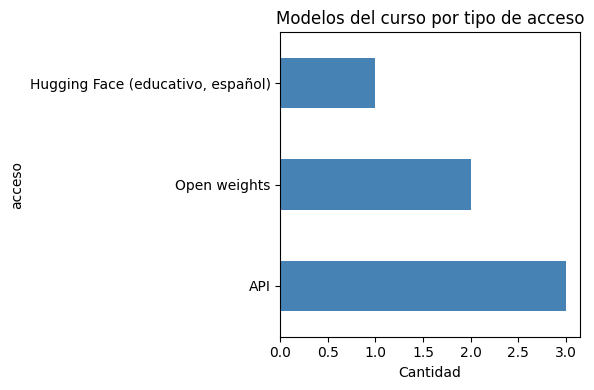

In [26]:
conteo = llms['acceso'].value_counts()
plt.figure(figsize=(6, 4))
conteo.plot(kind='barh', color='steelblue')
plt.title('Modelos del curso por tipo de acceso')
plt.xlabel('Cantidad')
plt.tight_layout()
plt.show()

## Resultados
Contrastamos IA discriminativa vs generativa, revisamos LLMs actuales y demostramos generacion autoregresiva con GPT-2 en español.

## Conclusiones
Los LLMs no son magia: predicen tokens. Su valor en produccion depende de como los instruyas (prompt engineering) y como mitigues sus limites.

## Ejercicios guiados resueltos
**Ejercicio:** Genera 3 continuaciones de 'El futuro de la IA' con temperatura 0.3, 0.7 y 1.2.

**Solucion:**

In [27]:
for temp in [0.3, 0.7, 1.2]:
    t = generar('El futuro de la inteligencia artificial', max_new_tokens=25, temperature=temp)
    print(f'T={temp}: {t}')
    print('-' * 50)

T=0.3: El futuro de la inteligencia artificial se ha visto truncada por la crisis del petróleo y la crisis del carbón.

La crisis del petróleo ha afectado a
--------------------------------------------------
T=0.7: El futuro de la inteligencia artificial al medio ambiente, sin embargo, sus investigaciones se centraron más en el concepto de "neutralización". La tecnología de
--------------------------------------------------
T=1.2: El futuro de la inteligencia artificial". En diciembre se anunció que «las tecnologías de creación de la Inteligencia Artificial para el Desarrollo no están bien desarrolladas.» Los
--------------------------------------------------


## Ejercicios propuestos
1. Investiga parametros de Llama 3 y Mistral 7B.
2. Lista 3 casos de uso de IA generativa en tu industria.
3. Explica por que un LLM puede alucinar datos especificos.

## Preguntas de reflexion
1. Que relacion hay entre decoder-only y generacion de texto?
2. Cuando preferirias un modelo open-weight vs API comercial?
3. Que riesgo tiene desplegar un LLM sin verificacion humana?